# Exploratory Data Analysis - Sample Superstore

## Objective
To explore the Sample Superstore dataset and identify important
patterns, relationships, outliers, and trends using statistical
analysis and data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 1. Understanding the Dataset

In [6]:
df.shape

(9994, 13)

In [8]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [10]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [11]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [12]:
(df.isnull().sum() / len(df)) * 100

Ship Mode       0.0
Segment         0.0
Country         0.0
City            0.0
State           0.0
Postal Code     0.0
Region          0.0
Category        0.0
Sub-Category    0.0
Sales           0.0
Quantity        0.0
Discount        0.0
Profit          0.0
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(17)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

## 2. Summary Statistics

In [16]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [17]:
df.describe(include='object')

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
count,9977,9977,9977,9977,9977,9977,9977,9977
unique,4,3,1,531,49,4,3,17
top,Standard Class,Consumer,United States,New York City,California,West,Office Supplies,Binders
freq,5955,5183,9977,914,1996,3193,6012,1522


In [18]:
df.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

## 3. Visualization 1 - Distribution of Sales

### Question
How are sales values distributed across orders?

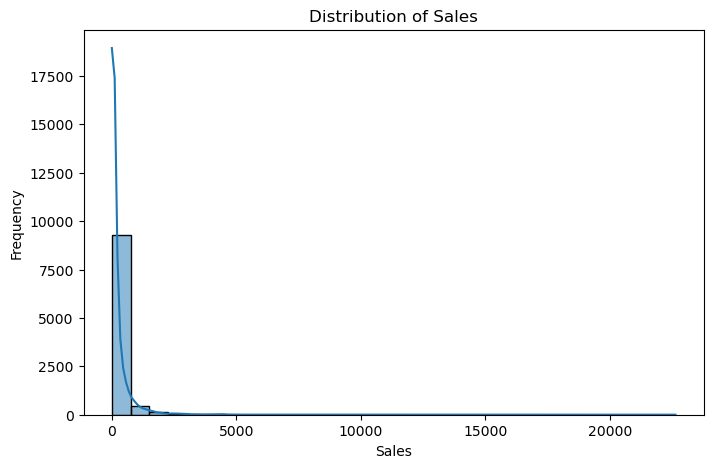

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30, kde=True)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

### Observation

The sales distribution is right-skewed. Most orders have relatively
low sales values, while a smaller number of orders have very high
sales values.

## 4. Visualization 2 - Profit Outliers

### Question
Are there unusually high or low profit values?

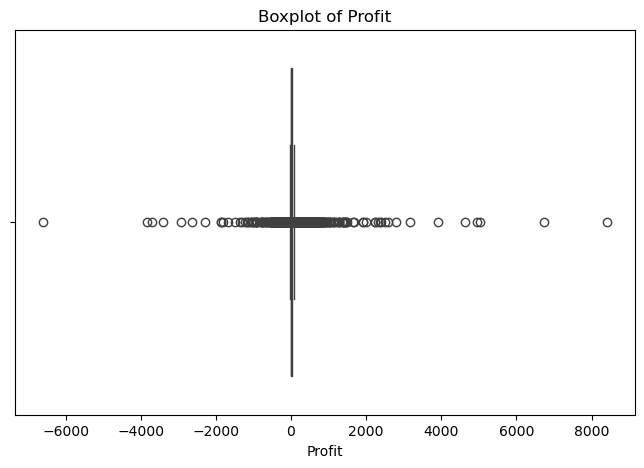

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Profit'])

plt.title('Boxplot of Profit')
plt.xlabel('Profit')

plt.show()

### Observation

The boxplot shows several observations that are far from the main
distribution of profit. These may represent unusually high profits
or losses and should be investigated further.

## 5. Visualization 3 - Correlation Analysis

### Question
What relationships exist between Sales, Quantity, Discount, and Profit?

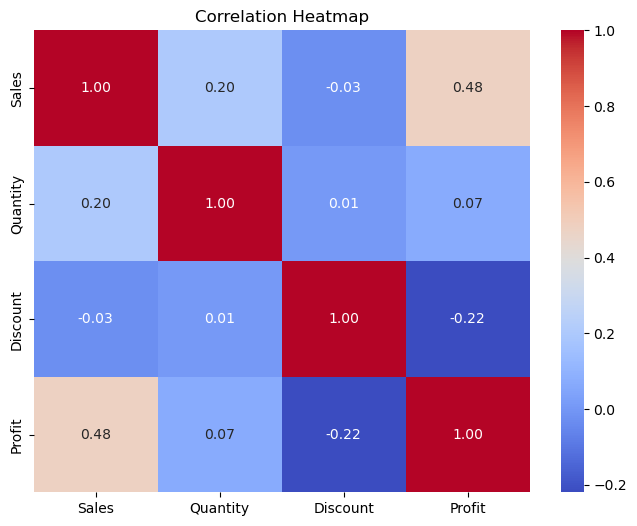

In [21]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

correlation = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Observation

Sales and Profit show a positive relationship, although the
relationship is not perfect. Discount should also be examined because
higher discounts may be associated with lower profitability.

## 6. Visualization 4 - Sales by Category

### Question
Which product category generates the highest sales?

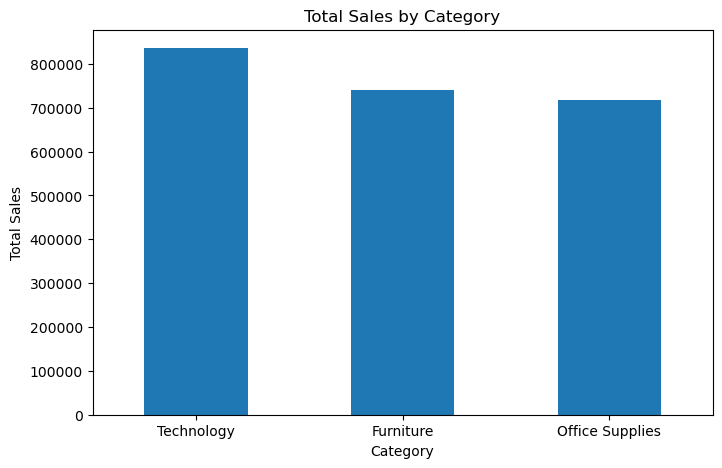

In [22]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)

plt.show()

### Observation

Technology has the highest total sales among the three categories,
while Office Supplies has lower total sales.

## 7. Visualization 5 - Profit by Region

### Question
Which region generates the highest total profit?

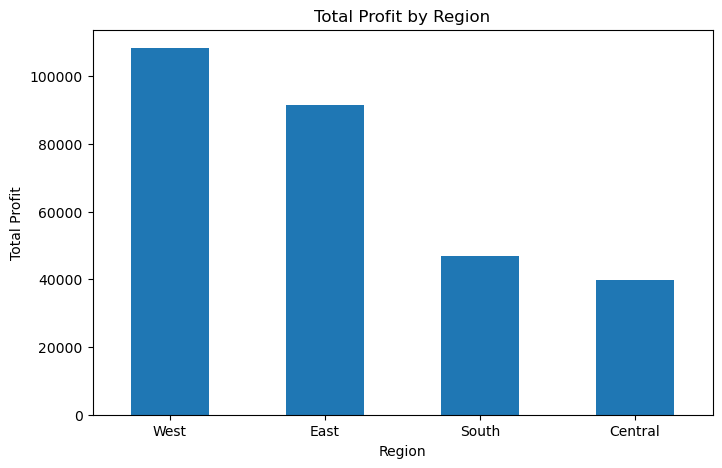

In [23]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

region_profit.plot(kind='bar')

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.xticks(rotation=0)

plt.show()

### Observation

The West region generates the highest total profit, while the
Central region generates comparatively lower profit.

## 8. Additional Analysis - Discount vs Profit

### Question
How does discount relate to profit?

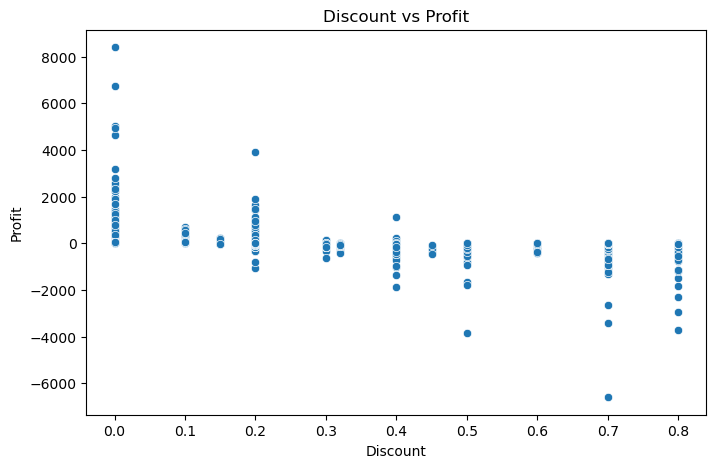

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

### Observation

The scatter plot suggests that higher discount levels are often
associated with lower profit values. However, this relationship alone
does not prove that discount directly causes lower profit.

# Top 3 Insights

## Top 3 Insights

1. Sales are strongly concentrated among relatively small orders,
   while a small number of orders have very high sales values.

2. Some transactions have unusually high or low profit values,
   which appear as potential outliers in the boxplot.

3. There are noticeable differences in sales and profitability
   across product categories and regions.

# Conclusion

The exploratory data analysis of the Sample Superstore dataset
revealed important patterns in sales, profit, discount, product
categories, and geographical regions.

The analysis also identified potential outliers in profit and showed
relationships between numerical variables through correlation and
scatterplot analysis.

These findings provide a better understanding of the dataset and
demonstrate how statistical analysis and visualization can be used
before making business conclusions.

## 3. Visualization 1 - Distribution of Sales

### Question
How are the Sales values distributed across orders?

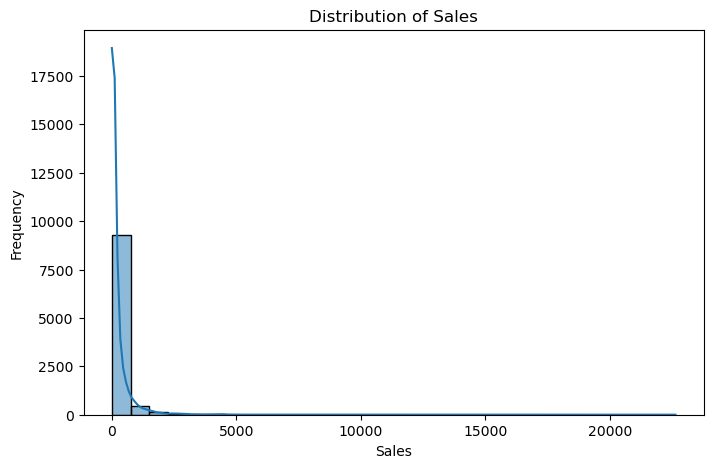

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Sales'], bins=30, kde=True)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

### Observation

The sales distribution is right-skewed. Most orders have relatively
low sales values, while a smaller number of orders have substantially
higher sales values.

## 4. Visualization 2 - Profit Outliers

### Question
Are there unusually high or low profit values?

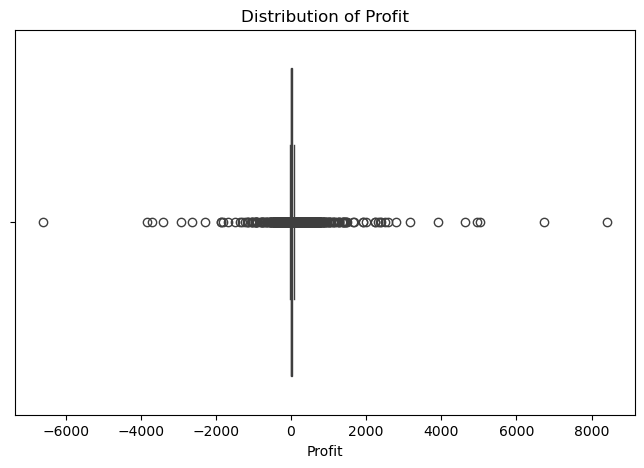

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Profit'])

plt.title('Distribution of Profit')
plt.xlabel('Profit')

plt.show()

### Observation

The boxplot shows several potential outliers in the profit values.
These observations are substantially different from the main
distribution and may represent unusually large profits or losses.

## 5. Visualization 3 - Correlation Analysis

### Question
How are Sales, Quantity, Discount, and Profit related to each other?

In [27]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

correlation = df[numeric_cols].corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200722,-0.028311,0.479067
Quantity,0.200722,1.000000,0.008678,0.066211
Discount,-0.028311,0.008678,1.000000,-0.219662
Profit,0.479067,0.066211,-0.219662,1.000000


### Observation

The correlation heatmap shows the relationships between Sales,
Quantity, Discount, and Profit. Sales and Profit show a positive
relationship, while Discount and Profit should be examined for a
possible negative relationship. However, correlation does not prove
that one variable causes changes in another.